# Water mass heat transport

In this code we will try to implement the same approach used for the ASC roject, which is to use the age along the isobath to define the DSW

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d

import xarray as xr
import cf_xarray as cfxr
import glob
import gsw

In [2]:
client = Client(n_workers=48)

In [3]:
#panan01 daily as f(z,time)
src_p01 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSsaltT_daily_z/*'
#panan005 daily as f(z,time)
src_p005 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSsaltT_daily_z/*'

start_time='2001-01'
end_time='2001-12'
lat_slice  = slice(-83,-59)
figdir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/figs/'


### Importing salt transport
#importing panan01
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_ST=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

#importing panan005
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_ST=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

12 netcdf data files
12 netcdf data files


In [4]:
### Panan01 Daily CSHT(z)
src_p01='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_daily_z/*'
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})
p01_HT_total = (p01_HT.unbinned_heat_transp_across_contour.mean('time').sum('contour_index').sum()/1e12).compute()

### Panan01 monthly CSHT(rho)
src_p01='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_month_rhoonline/*'
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
pρ01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested')
pρ01_HT=pρ01_HT.sel(time=slice(start_time,end_time))
pρ01_HT_total= pρ01_HT.unbinned_heat_transp_across_contour.sum('contour_index').load()
pρ01_HT_contour= ((pρ01_HT.binned_cross_slope_heat_trans + pρ01_HT.zonal_convergence)*0.08).mean('time').load()

12 netcdf data files
24 netcdf data files


In [5]:
### Panan005 Daily CSHT(z)
src_p005='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSHT_daily_z/*'
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})
p005_HT_total = (p005_HT.unbinned_heat_transp_across_contour.mean('time').sum('contour_index').sum()/1e12).compute()

### Panan005 monthly CSHT(rho)
src_p005='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSHT_month_rhoonline/*'
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
pρ005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested')
pρ005_HT=pρ005_HT.sel(time=slice(start_time,end_time))
pρ005_HT_total= pρ005_HT.unbinned_heat_transp_across_contour.sum('contour_index').load()
pρ005_HT_contour= ((pρ005_HT.binned_cross_slope_heat_trans + pρ005_HT.zonal_convergence)*0.08).mean('time').load()

12 netcdf data files
24 netcdf data files


In [6]:
### Panan005 monthly CSHT(rho)
src_p0025='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025/CSHT_month_rhoonline/*'
gl =glob.glob(src_p0025)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
pρ0025_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested')
pρ0025_HT=pρ0025_HT.sel(time=slice(start_time,end_time))
pρ0025_HT_total= pρ0025_HT.unbinned_heat_transp_across_contour.sum('contour_index').load()
pρ0025_HT_contour= ((pρ0025_HT.binned_cross_slope_heat_trans + pρ0025_HT.zonal_convergence)*0.08).mean('time').load()

12 netcdf data files


In [7]:
pρ01_HT.isel(time=0).unbinned_heat_transp_across_contour.sum().values,pρ005_HT.isel(time=0).unbinned_heat_transp_across_contour.sum().values, pρ0025_HT.isel(time=0).unbinned_heat_transp_across_contour.sum().values

(array(-5.4267063e+13, dtype=float32),
 array(-5.917037e+13, dtype=float32),
 array(-5.9242246e+13, dtype=float32))

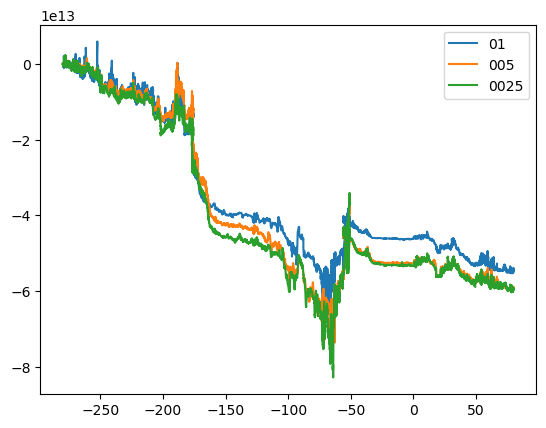

In [11]:
plt.plot(pρ01_HT.lon_along_contour[0],pρ01_HT.isel(time=0).\
         unbinned_heat_transp_across_contour.sum('rho2_l').cumsum(),label='01')
plt.plot(pρ005_HT.lon_along_contour[0],pρ005_HT.isel(time=0).\
         unbinned_heat_transp_across_contour.sum('rho2_l').cumsum(),label='005')
plt.plot(pρ0025_HT.lon_along_contour[0],pρ0025_HT.isel(time=0).\
         unbinned_heat_transp_across_contour.sum('rho2_l').cumsum(),label='0025')
plt.legend()

  plt.plot(p005_ST.isel(time=0).lon_along_contour.drop('time'),

  p005_ST.isel(time=0).lat_along_contour.drop('time'), color='grey')



(-80.0, -58.0)

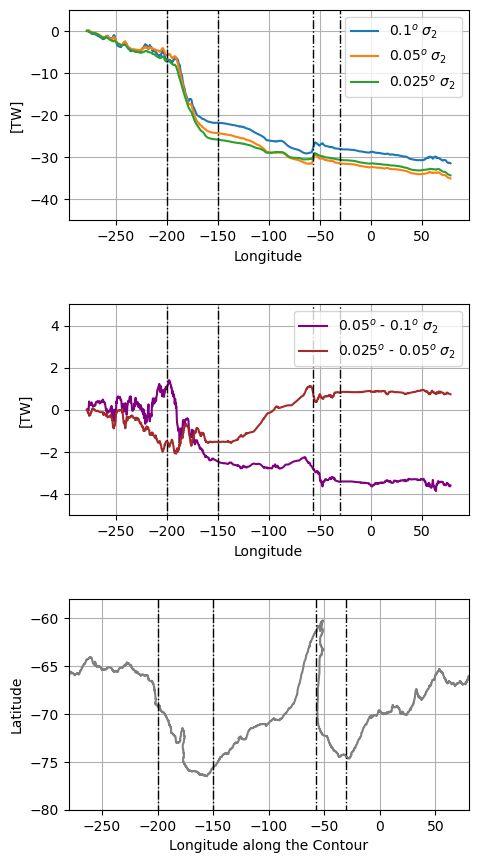

In [12]:
plt.figure(figsize=(5, 10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.4)

plt.subplot(3,1,1)
 
(((pρ01_HT.binned_cross_slope_heat_trans + pρ01_HT.zonal_convergence)*0.08).mean('time')\
    .sum('rho2_l').cumsum()/1e12).plot(label=r'$0.1^o$ $\sigma_2$')
(((pρ005_HT.binned_cross_slope_heat_trans + pρ005_HT.zonal_convergence)*0.08).mean('time')\
    .sum('rho2_l').cumsum()/1e12).plot(label=r'$0.05^o$ $\sigma_2$')
(((pρ0025_HT.binned_cross_slope_heat_trans + pρ0025_HT.zonal_convergence)*0.08).mean('time')\
    .sum('rho2_l').cumsum()/1e12).plot(label=r'$0.025^o$ $\sigma_2$')
plt.plot([-200,-200],[-45,5],lw=1,color='k',linestyle='-.')
plt.plot([-150,-150],[-45,5],lw=1,color='k',linestyle='-.')
plt.plot([-57,-57],[-45,5],lw=1,color='k',linestyle='-.')
plt.plot([-30,-30],[-45,5],lw=1,color='k',linestyle='-.')
plt.grid(); plt.ylim(-45,5)
plt.legend()
plt.ylabel(r'[TW]')
plt.xlabel(r'Longitude')

plt.subplot(3,1,2)
(( (((pρ005_HT.binned_cross_slope_heat_trans + pρ005_HT.zonal_convergence)*0.08).mean('time').sum('rho2_l').cumsum()) - (((pρ01_HT.binned_cross_slope_heat_trans + pρ01_HT.zonal_convergence)*0.08).mean('time').sum('rho2_l').cumsum()) )/1e12)\
    .plot(color='purple',label=r'$0.05^o$ - $0.1^o$ $\sigma_2$')

(( (((pρ0025_HT.binned_cross_slope_heat_trans + pρ0025_HT.zonal_convergence)*0.08).mean('time').sum('rho2_l').cumsum()) - (((pρ005_HT.binned_cross_slope_heat_trans + pρ005_HT.zonal_convergence)*0.08).mean('time').sum('rho2_l').cumsum()) )/1e12)\
    .plot(color='brown',label=r'$0.025^o$ - $0.05^o$ $\sigma_2$')
plt.plot([-200,-200],[-45,5],lw=1,color='k',linestyle='-.')
plt.plot([-150,-150],[-45,5],lw=1,color='k',linestyle='-.')
plt.plot([-57,-57],[-45,5],lw=1,color='k',linestyle='-.')
plt.plot([-30,-30],[-45,5],lw=1,color='k',linestyle='-.')
plt.ylabel(r'[TW]');plt.ylim(-5,5)
plt.xlabel(r'Longitude')
plt.grid()
plt.legend()

plt.subplot(3,1,3)
plt.plot(p005_ST.isel(time=0).lon_along_contour.drop('time'),
         p005_ST.isel(time=0).lat_along_contour.drop('time'), color='grey')
plt.xlabel('Longitude along the Contour'); plt.xlim(-280,80)
plt.plot([-200,-200],[-85,-55],lw=1,color='k',linestyle='-.')
plt.plot([-150,-150],[-85,-55],lw=1,color='k',linestyle='-.')
plt.plot([-57,-57],[-85,-55],lw=1,color='k',linestyle='-.')
plt.plot([-30,-30],[-85,-55],lw=1,color='k',linestyle='-.')
plt.grid() ;plt.ylabel('Latitude')
plt.ylim(-80,-58)

It seems that changes in heat transport are very regional. 

**In the East Antarctica** [West of $200^oW$]: the CSHT increases  by $2\ TW$ only when going to the highest resolution (i.e., from $0.05^o$ to $0.025^o$). This suggestst that we only start increasing some of the edyd flow in the higher resolution in the simulation

**In the Ross Sea** [$200^oW$ $150^oW$]: there is a progressive increase in CSHT between all resolutions. Specifically, a $2.5\ TW$ increase from $0.1^o$ to $0.05^o$, and a $1\ TW$ increase from $0.05^o$ to $0.025^o$.

**In the West of the Antarctic Peninsula** [$120^oW$ $60^oW$]: It seems that a decrease in CSHT happens from $0.05^o$ to $0.025^o$ ( about $1\ TW$ decrease)

**In the Eastern Weddell Sea** [$60^oW$ $50^oW$]: Once again a $1\ TW$ increase in in CSHT happens from $0.1^o$ to $0.05^o$. This increase is not seen on the higher resolution case.


In [13]:
#importing mass transports
MT01=xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/vol_transp_across_1000m_isobath_panan_01deg_jra55_ryf_1m_2000.nc')
MT005=xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/vol_transp_across_1000m_isobath_panan_005deg_jra55_ryf_1m_2000.nc')
MT0025=xr.open_mfdataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/vol_transp_across_1000m_isobath_panan_0025deg_jra55_ryf_1m_2000*.nc')
refsigma=np.array(MT01.rho2_l) #target sigmas to interpoalte

MT0025mean=MT0025.vol_trans_across_contour.mean('time')
MT005mean=MT005.vol_trans_across_contour.mean('time')
MT01mean=MT01.vol_trans_across_contour.mean('time')

# Mean CSST

Notice that the salt transport is in Kg of salt per sec

In [14]:
mp01_ST = p01_ST.groupby('time.month').mean('time').mean('month').sum('z_l')
mp005_ST = p005_ST.groupby('time.month').mean('time').mean('month').sum('z_l')
mzp01_ST = p01_ST.groupby('time.month').mean('time').mean('month')
mzp005_ST = p005_ST.groupby('time.month').mean('time').mean('month')


INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:find_group_cohorts: blockwise is preferred.
INFO:flox:_choose_method: method is None
INFO:flox:_choose_method: choosing preferred_method=blockwise
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: reindex is False
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:find_group_cohorts: blockwise is preferred.
INFO:flox:_choose_method: method is None
INFO:flox:_choose_method: choosing preferred_method=blockwise
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: reindex is False
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engin

In [15]:
#Calculating binned and unbinned vars and cumsum - PANAN01
mp01_STunbinned=mp01_ST.unbinned_salt_transp_across_contour.cumsum()
factor01=mp01_STunbinned.max()/( (mp01_ST.binned_cross_slope_salt_trans.sum()) + (mp01_ST.zonal_convergence.sum())  )
mp01_STbinned=(mp01_ST.binned_cross_slope_salt_trans*factor01).cumsum()
mp01_STZC=(mp01_ST.zonal_convergence*factor01).cumsum()
mp01_STbinnedZC=( (mp01_ST.binned_cross_slope_salt_trans + mp01_ST.zonal_convergence)*factor01 ).cumsum()

#Calculating binned and unbinned vars and cumsum - PANAN005
mp005_STunbinned=mp005_ST.unbinned_salt_transp_across_contour.cumsum()
factor005=mp005_STunbinned.max()/( (mp005_ST.binned_cross_slope_salt_trans.sum()) + (mp005_ST.zonal_convergence.sum())  )
mp005_STbinned=(mp005_ST.binned_cross_slope_salt_trans*factor005).cumsum()
mp005_STZC=(mp005_ST.zonal_convergence*factor005).cumsum()
mp005_STbinnedZC=( (mp005_ST.binned_cross_slope_salt_trans + mp005_ST.zonal_convergence)*factor005 ).cumsum()

In [16]:
# Here we are assuming that all negative salt transport is due to the CDW
CDWmzp01_ST=( mzp01_ST.binned_cross_slope_salt_trans + mzp01_ST.zonal_convergence)*factor01
CDWmzp01_ST=CDWmzp01_ST.where(CDWmzp01_ST<0).sum('z_l')

CDWmzp005_ST=( mzp005_ST.binned_cross_slope_salt_trans + mzp005_ST.zonal_convergence)*factor005
CDWmzp005_ST=CDWmzp005_ST.where(CDWmzp005_ST<0).sum('z_l')


First evaluation for CSST, how does it compareto the zonal convegence on panan01?

  plt.plot(p005_ST.isel(time=0).lon_along_contour.drop('time'),

  p005_ST.isel(time=0).lat_along_contour.drop('time'), color='grey')



Text(0.5, 1.0, 'Sum of Southward Transports')

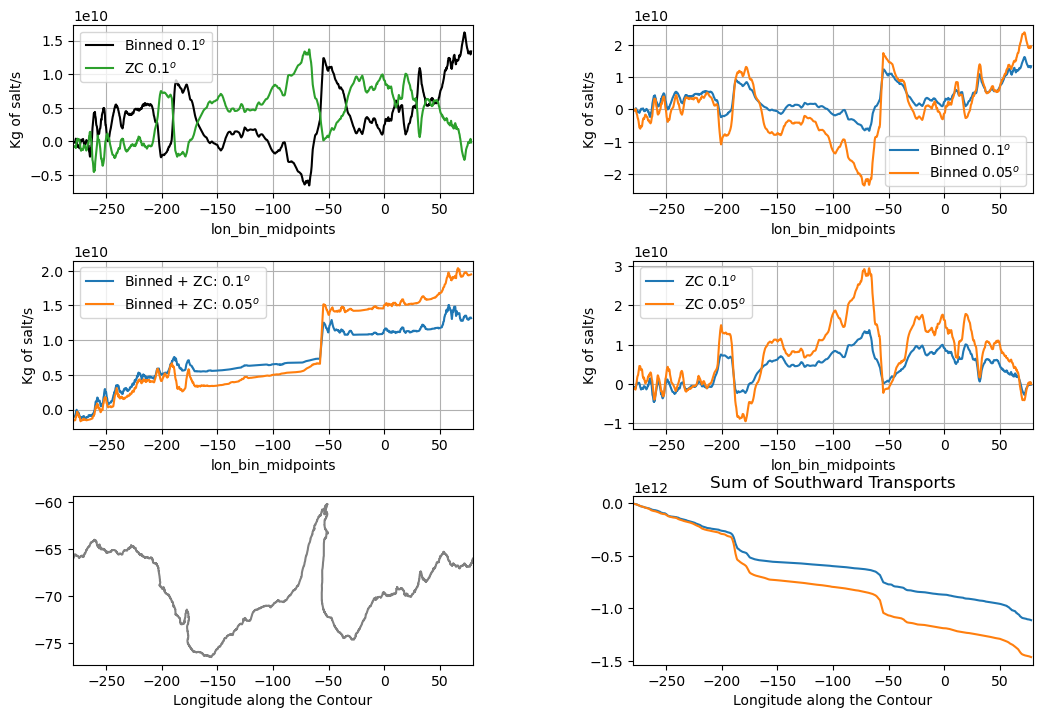

In [17]:
plt.figure(figsize=(12, 8))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(3,2,1)
(factor01*mp01_STbinned).plot(color='black',label=r"Binned $0.1^o$")
(factor01*mp01_STZC).plot(color='tab:green',label=r"ZC $0.1^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s')

plt.subplot(3,2,2)
(factor01*mp01_STbinned).plot(color='tab:blue',label=r"Binned $0.1^o$")
(factor005*mp005_STbinned).plot(color='tab:orange',label=r"Binned $0.05^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s');


plt.subplot(3,2,3)
(factor01*mp01_STbinnedZC).plot(color='tab:blue',label=r"Binned + ZC: $0.1^o$")
(factor005*mp005_STbinnedZC).plot(color='tab:orange',label=r"Binned + ZC: $0.05^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s')


plt.subplot(3,2,4)
(factor01*mp01_STZC).plot(color='tab:blue',label=r"ZC $0.1^o$")
(factor005*mp005_STZC).plot(color='tab:orange',label=r"ZC $0.05^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s');

plt.subplot(3,2,5)
plt.plot(p005_ST.isel(time=0).lon_along_contour.drop('time'),
         p005_ST.isel(time=0).lat_along_contour.drop('time'), color='grey')
plt.xlabel('Longitude along the Contour'); plt.xlim(-280,80)


plt.subplot(3,2,6)
CDWmzp01_ST.cumsum().plot(color='tab:blue',label=r"CDW $0.1^o$")
CDWmzp005_ST.cumsum().plot(color='tab:orange',label=r"ZC $0.05^o$")
plt.xlabel('Longitude along the Contour'); plt.xlim(-280,80)
plt.title('Sum of Southward Transports')

What do we take from these plots?

1- It seems to me that the zonal convergence largely compensate the CSSalt transport (top)

2- There are 3 main regions where the salt Southward salt transport is so strong that it actually can be seen in the cumulative sum. one is around 280W, then ross sea (~200W), and amundsen sea (-200,-150)

3- In the 3 regions above, the Southward Salt transport increase with resolution ( More southward salt transport as resolution increases)

4- the signals in the zonal convergence increase with resolution too

5- the total CCSalt transport is positive (northward) in all cases, and increases with resolution

6- For the plot on bottom left we assumed all Southward Transport corresponds to CDW entrance. If that assumption is valid, than the stronger negative salt tranport in the higher resolution suggests that we likely have more CDW entering the shelf in higher resolutions


# Transports along isopycnals

In [18]:
#importing heat transports
#panan01 daily as f(z,time)
src_p01 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_daily_z/*'
#panan005 daily as f(z,time)
src_p005 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSHT_daily_z/*'
#panan0025 daily as f(z,time)
src_p0025 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025/CSHT_monthly_z/*'

#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

#importing panan005
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

meanp01_HT=p01_HT.groupby('time.month').mean('time').mean('month')
meanp005_HT=p005_HT.groupby('time.month').mean('time').mean('month')

12 netcdf data files
12 netcdf data files


INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:find_group_cohorts: blockwise is preferred.
INFO:flox:_choose_method: method is None
INFO:flox:_choose_method: choosing preferred_method=blockwise
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: reindex is False
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engine: Choosing 'flox'
INFO:flox:find_group_cohorts: blockwise is preferred.
INFO:flox:_choose_method: method is None
INFO:flox:_choose_method: choosing preferred_method=blockwise
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: reindex is False
INFO:flox:Entering _validate_reindex: reindex is None
INFO:flox:Leaving _validate_reindex: method = None, returning None
INFO:flox:_choose_engin

In [19]:
figdir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [20]:
pρ01_HT_totalmeanGW = (pρ01_HT_total.mean('time')[::-1].cumsum('rho2_l')/1e12)
pρ01_HT_totalmeanGW_nocumsum = (pρ01_HT_total.mean('time')[::-1]/1e12)

pρ005_HT_totalmeanGW = (pρ005_HT_total.mean('time')[::-1].cumsum('rho2_l')/1e12)
pρ005_HT_totalmeanGW_nocumsum = (pρ005_HT_total.mean('time')[::-1]/1e12)

pρ0025_HT_totalmeanGW = (pρ0025_HT_total.mean('time')[::-1].cumsum('rho2_l')/1e12)
pρ0025_HT_totalmeanGW_nocumsum = (pρ0025_HT_total.mean('time')[::-1]/1e12)

In order to calcualte the mean temperature of each layer we need to import the volumet ofmlayer ( for averaging)

In [24]:
#Session
session2 = cc.database.create_session('/home/156/wf4500/databases/access/panan_BUsigma.db')
end_time='2001-12'
start_time='2001-01'


# #on panan01
# volcello01 = cc.querying.getvar('panan01_yr2000_HTsigma','volcello',session2,ncfile='%month_rho2.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# T01ρ = cc.querying.getvar('panan01_yr2000_HTsigma','thetao',session2,ncfile='%month_rho2.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# T01z = cc.querying.getvar('panan01_yr2000_HTsigma','thetao',session2,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# S01z = cc.querying.getvar('panan01_yr2000_HTsigma','so',session2,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# S01zmean = S01z.mean('time')
# T01zmean =  T01z.mean('time')
# T01ρmean = T01ρ.mean('time')
# Vol01ρmean = volcello01.mean('time')

# # #on panan005
# volcello005 = cc.querying.getvar('panan005_yr2000_HTsigma','volcello',session2,ncfile='%month_rho2.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# T005ρ = cc.querying.getvar('panan005_yr2000_HTsigma','thetao',session2,ncfile='%month_rho2.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# T005z = cc.querying.getvar('panan005_yr2000_HTsigma','thetao',session2,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# S005z = cc.querying.getvar('panan005_yr2000_HTsigma','so',session2,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# S005zmean = S005z.mean('time')
# T005zmean = T005z.mean('time')
# T005ρmean = T005ρ.mean('time')
# Vol005ρmean = volcello005.mean('time')

# # #on panan0025
# volcello0025 = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','volcello',session2,ncfile='%month_rho2.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# T0025ρ = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','thetao',session2,ncfile='%month_rho2.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# T0025z = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','thetao',session2,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# S0025z = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','so',session2,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-50))
# S0025zmean = S0025z.mean('time')
# T0025zmean = T0025z.mean('time')
# T0025ρmean = T0025ρ.mean('time')
# Vol0025ρmean = volcello0025.mean('time')


Now lets get the T and vol values along the contour

In [25]:
# #0.1
# T01ρmean_contour = T01ρmean.sel(yh=pρ01_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ01_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# Vol01ρmean_contour = Vol01ρmean.sel(yh=pρ01_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ01_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# T01zmean_contour = T01zmean.sel(yh=pρ01_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ01_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# S01zmean_contour = S01zmean.sel(yh=pρ01_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ01_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')



# #0.05 #Changer that later once we have the values along contour
# T005ρmean_contour = T005ρmean.sel(yh=pρ005_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ005_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# Vol005ρmean_contour = Vol005ρmean.sel(yh=pρ005_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ005_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# T005zmean_contour = T005zmean.sel(yh=pρ005_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ005_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# S005zmean_contour = S005zmean.sel(yh=pρ005_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ005_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')


# #0.025 #Changer that later once we have the values along contour
# T0025ρmean_contour = T0025ρmean.sel(yh=pρ0025_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ0025_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# Vol0025ρmean_contour = Vol0025ρmean.sel(yh=pρ0025_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ0025_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# T0025zmean_contour = T0025zmean.sel(yh=pρ0025_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ0025_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')
# S0025zmean_contour = S0025zmean.sel(yh=pρ0025_HT.lat_along_contour.isel(time=0).drop('time'),xh=pρ0025_HT.lon_along_contour.isel(time=0).drop('time'),method='nearest')

In [26]:
# #densities for TS diagram
# salt_bins01 = np.arange(np.floor(S01zmean_contour.min().values), np.ceil(S01zmean_contour.max().values), 0.1)
# temp_bins01 = np.arange(np.floor(T01zmean_contour.min().values), np.ceil(T01zmean_contour.max().values)+0.5, 0.5)
# temp_bins_mesh01,salt_bins_mesh01 = np.meshgrid(temp_bins01, salt_bins01)
# TS_density01 = gsw.density.sigma2(salt_bins_mesh01, temp_bins_mesh01)


# salt_bins005 = np.arange(np.floor(S005zmean_contour.min().values), np.ceil(S005zmean_contour.max().values), 0.1)
# temp_bins005 = np.arange(np.floor(T005zmean_contour.min().values), np.ceil(T005zmean_contour.max().values)+0.5, 0.5)
# temp_bins_mesh005,salt_bins_mesh005 = np.meshgrid(temp_bins005, salt_bins005)
# TS_density005 = gsw.density.sigma2(salt_bins_mesh005, temp_bins_mesh005)



# salt_bins0025 = np.arange(np.floor(S0025zmean_contour.min().values), np.ceil(S0025zmean_contour.max().values), 0.1)
# temp_bins0025 = np.arange(np.floor(T0025zmean_contour.min().values), np.ceil(T0025zmean_contour.max().values)+0.5, 0.5)
# temp_bins_mesh0025,salt_bins_mesh0025 = np.meshgrid(temp_bins0025, salt_bins0025)
# TS_density0025 = gsw.density.sigma2(salt_bins_mesh0025, temp_bins_mesh0025)

How does the full contour TS diagrams look like in each resolution?

In [28]:
# plt.figure(figsize=(16, 4))
# plt.subplots_adjust(left=0.1,
#                     bottom=0.1, 
#                     right=0.9, 
#                     top=0.9, 
#                     wspace=0.3, 
#                     hspace=0.4)



# plt.subplot(1,3,1)
# plt.scatter(S01zmean_contour,T01zmean_contour,s=1)
# plt.colorbar()
# plt.xlim(33.55,34.8)

# levels01=np.arange(np.floor(TS_density01.min())+0.05,
#                                   np.ceil(TS_density01.max()), .2)
# levels01=np.sort(np.append(np.append(levels01,37.14),36.75)) #adding the level used to define the DSW in panan005
# cs01 = plt.contour(
#     salt_bins_mesh01, temp_bins_mesh01, TS_density01, colors='black',
#                  levels=levels01)
# plt.plot([33.55,34.8],[-1,-1],color='tab:red')
# plt.clabel(cs01, inline=True)
# plt.xlabel('Salinity'); plt.ylabel(r"Temperature [$^oC$]")
# plt.title(r"[a] $0.1^o$")


# plt.subplot(1,3,2)
# plt.scatter(S005zmean_contour,T005zmean_contour,s=1)
# plt.colorbar()
# plt.xlim(33.55,34.8)

# levels005=np.arange(np.floor(TS_density005.min())+0.05,
#                                   np.ceil(TS_density005.max()), .2)
# levels005=np.sort(np.append(np.append(levels005,37.14),36.75)) #adding the level used to define the DSW in panan005
# cs005 = plt.contour(
#     salt_bins_mesh005, temp_bins_mesh005, TS_density005, colors='black',
#                  levels=levels005)
# plt.plot([33.55,34.8],[-1,-1],color='tab:red')
# plt.clabel(cs005, inline=True)
# plt.xlabel('Salinity'); plt.ylabel(r"Temperature [$^oC$]")
# plt.title(r"[b] $0.05^o$")

# plt.subplot(1,3,3)
# plt.scatter(S0025zmean_contour,T0025zmean_contour,s=1)
# plt.colorbar()
# plt.xlim(33.55,34.8)

# levels0025=np.arange(np.floor(TS_density0025.min())+0.05,
#                                   np.ceil(TS_density0025.max()), .2)
# levels0025=np.sort(np.append(np.append(levels0025,37.14),36.75)) #adding the level used to define the DSW in panan005
# cs0025 = plt.contour(
#     salt_bins_mesh0025, temp_bins_mesh0025, TS_density0025, colors='black',
#                  levels=levels0025)
# plt.plot([33.55,34.8],[-1,-1],color='tab:red')
# plt.clabel(cs0025, inline=True)
# plt.xlabel('Salinity'); plt.ylabel(r"Temperature [$^oC$]")
# plt.title(r"[c] $0.025^o$")

It seems to me that $\sigma_2\ >\ 36.75\ kg\ m^{-3}$ and $T > 0^oC$ would be aan appropriate definition for CDW here. We can use that later on. Other interesting thigns we can see is...

DSW seem to get colder and colder values with higher resolution. and CDW seem to have fresher values in the highest resolution

In [29]:
# # mean temperature along the contour will be
# T01ρmean_contourmean = T01ρmean_contour.weighted(Vol01ρmean_contour.fillna(0)).mean('contour_index').load()
# T005ρmean_contourmean = T005ρmean_contour.weighted(Vol005ρmean_contour.fillna(0)).mean('contour_index').load()
# T0025ρmean_contourmean = T0025ρmean_contour.weighted(Vol0025ρmean_contour.fillna(0)).mean('contour_index').load()

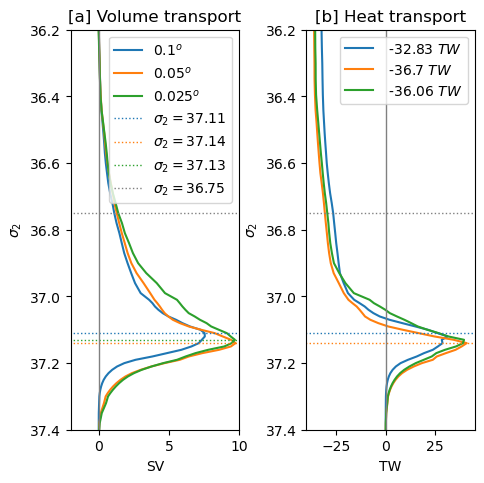

In [30]:
plt.figure(figsize=(8, 5))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(1,3,1)
plt.plot(MT01.mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot(MT0025.mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT0025.rho2_l[::-1]-1000,color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.11,37.11],':',color='tab:blue',lw=1,label=r"$\sigma_2=37.11$")
plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1,label=r"$\sigma_2=37.14$")
plt.plot([-5,15],[37.13,37.13],':',color='tab:green',lw=1,label=r"$\sigma_2=37.13$")
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1,label=r"$\sigma_2=36.75$")

plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('SV'),plt.ylabel(r"$\sigma_2$");plt.title('[a] Volume transport')
plt.ylim(37.4,36.2); plt.xlim(-2,10)
plt.legend()

total01= np.round(pρ01_HT_totalmeanGW_nocumsum.sum(),2)
total005= np.round(pρ005_HT_totalmeanGW_nocumsum.sum(),2)
total0025= np.round(pρ0025_HT_totalmeanGW_nocumsum.sum(),2)

plt.subplot(1,3,2)
plt.plot(pρ01_HT_totalmeanGW,\
         pρ01_HT_totalmeanGW.rho2_l-1000, color='tab:blue',  label=r" " + str(total01.values) + " $TW$")
plt.plot(pρ005_HT_totalmeanGW,\
         pρ005_HT_totalmeanGW.rho2_l-1000, color='tab:orange',  label=r" " + str(total005.values) + " $TW$")
plt.plot(pρ0025_HT_totalmeanGW,\
         pρ0025_HT_totalmeanGW.rho2_l-1000, color='tab:green',  label=r" " + str(total0025.values) + " $TW$")
plt.plot([-50,50],[37.11,37.11],':',color='tab:blue',lw=1)
plt.plot([-50,50],[37.14,37.14],':',color='tab:orange',lw=1)
plt.plot([-50,50],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('TW'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.4,36.2);plt.xlim(-40,45); plt.legend()

# plt.subplot(1,3,3)
# plt.plot(T01ρmean_contourmean[::-1],\
#          T01ρmean_contourmean.rho2_l[::-1]-1000, color='tab:blue', label=r"$0.1^o$")
# plt.plot(T005ρmean_contourmean[::-1],\
#          T005ρmean_contourmean.rho2_l[::-1]-1000, color='tab:orange', label=r"$0.05^o$")
# plt.plot(T0025ρmean_contourmean[::-1],\
#          T0025ρmean_contourmean.rho2_l[::-1]-1000, color='tab:green', label=r"$0.025^o$")
# plt.plot([-5,15],[37.11,37.11],':',color='tab:blue',lw=1)
# plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1)
# plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1)
# plt.plot([0,0],[30,40],color='grey',linewidth=1)
# plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
# plt.ylim(37.4,36.2);plt.xlim(-2,1)


The circumpolar profiles of mass transport are in general just too similar to the one in heat transport. It seems to me that this only confirms that the general mean changes in CSHT between resolutions is due to DSW overflow.

--------
Lets calculate the volume transport of CDW in each simulation. I will use a minimum and maximum density layers shown above as constrains. I will also constraint only to places where the temperature is above $-1^oC$.

In [24]:
# for panan01 the slice is between 36.75 and 37.11
HT_CDW01 = pρ01_HT.mean('time').unbinned_heat_transp_across_contour.where(T01ρmean_contour>-1)\
    .sel(rho2_l=slice(1036.75,1037.11)).sum().values/1e12

# for panan01 the slice is between 36.75 and 37.14
HT_CDW005 = pρ005_HT.mean('time').unbinned_heat_transp_across_contour.where(T005ρmean_contour>-1)\
    .sel(rho2_l=slice(1036.75,1037.14)).sum().values/1e12

# for panan01 the slice is between 36.75 and 37.13
HT_CDW0025 = pρ0025_HT.mean('time').unbinned_heat_transp_across_contour.where(T0025ρmean_contour>-1)\
    .sel(rho2_l=slice(1036.75,1037.13)).sum().values/1e12



In [25]:
HT_CDW01,HT_CDW005,HT_CDW0025

(-41.610674962432, -42.916491821056, -47.151941943296)

Interestingly, we can see that the heat transported by CDW seem to increase very consistently with simulation.

### East Antarctica $[280^oW$ $200^oW]$

East Antarctica seem to be a particular place for our results, in the sense that the mean heat transport seem to change direction. Lets see how that looks like in a water mass space

In [26]:
EApρ01_HT_totalmeanGW = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-200)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
EApρ01_HT_totalmeanGW_nocumsum = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-200)[::-1].sum('lon_bin_midpoints')/1e12)

EApρ005_HT_totalmeanGW = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-200)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
EApρ005_HT_totalmeanGW_nocumsum = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-200)[::-1].sum('lon_bin_midpoints')/1e12)

EApρ0025_HT_totalmeanGW = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-200)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
EApρ0025_HT_totalmeanGW_nocumsum = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-200)[::-1].sum('lon_bin_midpoints')/1e12)

In [27]:
EAT01ρmean_contour  =T01ρmean_contour.where(pρ01_HT.lon_along_contour.isel(time=0)<-200).weighted(Vol01ρmean_contour.fillna(0)).mean('contour_index').load()
EAT01ρmeanscatter  =T01ρmean_contour.where(pρ01_HT.lon_along_contour.isel(time=0)<-200).load()

EAT005ρmean_contour  =T005ρmean_contour.where(pρ005_HT.lon_along_contour.isel(time=0)<-200).weighted(Vol005ρmean_contour.fillna(0)).mean('contour_index').load()
EAT005ρmeanscatter  =T01ρmean_contour.where(pρ005_HT.lon_along_contour.isel(time=0)<-200).load()

EAT0025ρmean_contour  =T0025ρmean_contour.where(pρ0025_HT.lon_along_contour.isel(time=0)<-200).weighted(Vol0025ρmean_contour.fillna(0)).mean('contour_index').load()
EAT0025ρmeanscatter  =T01ρmean_contour.where(pρ0025_HT.lon_along_contour.isel(time=0)<-200).load()

(-2.0, 1.0)

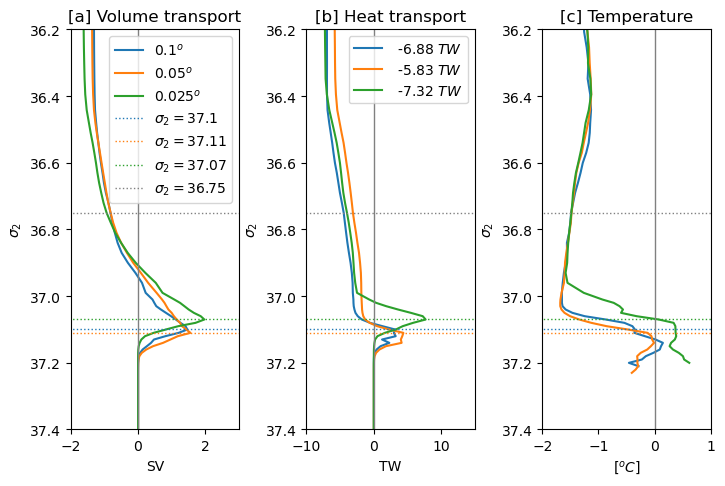

In [28]:
plt.figure(figsize=(8, 5))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(1,3,1)
plt.plot(MT01.where(MT01.lon<-200).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.where(MT01.lon<200).rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.where(MT005.lon<-200).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.where(MT005.lon<-200).rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot(MT0025.where(MT0025.lon<-200).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT0025.where(MT0025.lon<-200).rho2_l[::-1]-1000,color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.1,37.1],':',color='tab:blue',lw=1,label=r"$\sigma_2=37.1$")
plt.plot([-5,15],[37.11,37.11],':',color='tab:orange',lw=1,label=r"$\sigma_2=37.11$")
plt.plot([-5,15],[37.07,37.07],':',color='tab:green',lw=1,label=r"$\sigma_2=37.07$")
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1,label=r"$\sigma_2=36.75$")

plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('SV'),plt.ylabel(r"$\sigma_2$");plt.title('[a] Volume transport')
plt.ylim(37.4,36.2); plt.xlim(-2,3)
plt.legend()

EAtotal01= np.round(EApρ01_HT_totalmeanGW_nocumsum.sum(),2)
EAtotal005= np.round(EApρ005_HT_totalmeanGW_nocumsum.sum(),2)
EAtotal0025= np.round(EApρ0025_HT_totalmeanGW_nocumsum.sum(),2)
plt.subplot(1,3,2)
plt.plot(EApρ01_HT_totalmeanGW,\
         EApρ01_HT_totalmeanGW.rho2_l-1000, color='tab:blue', label=r" " + str(EAtotal01.values) + " $TW$")
plt.plot(EApρ005_HT_totalmeanGW,\
         EApρ005_HT_totalmeanGW.rho2_l-1000, color='tab:orange', label=r" " + str(EAtotal005.values) + " $TW$")
plt.plot(EApρ0025_HT_totalmeanGW,\
         EApρ0025_HT_totalmeanGW.rho2_l-1000, color='tab:green', label=r" " + str(EAtotal0025.values) + " $TW$")
plt.plot([-50,50],[37.1,37.1],':',color='tab:blue',lw=1)
plt.plot([-50,50],[37.11,37.11],':',color='tab:orange',lw=1)
plt.plot([-15,15],[37.07,37.07],':',color='tab:green',lw=1)
plt.plot([-50,50],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('TW'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.4,36.2);plt.xlim(-10,15); plt.legend()

plt.subplot(1,3,3)
plt.plot(EAT01ρmean_contour[::-1],\
         EAT01ρmean_contour.rho2_l[::-1]-1000, color='tab:blue', label=r"$0.1^o$")
plt.plot(EAT005ρmean_contour[::-1],\
         EAT005ρmean_contour.rho2_l[::-1]-1000, color='tab:orange', label=r"$0.05^o$")
plt.plot(EAT0025ρmean_contour[::-1],\
         EAT0025ρmean_contour.rho2_l[::-1]-1000, color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.1,37.1],':',color='tab:blue',lw=1)
plt.plot([-5,15],[37.11,37.11],':',color='tab:orange',lw=1)
plt.plot([-5,15],[37.07,37.07],':',color='tab:green',lw=1)
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
plt.ylim(37.4,36.2);plt.xlim(-2,1)

We can see that between $0.1^o$ and $0.05^o$ there are minimal changes in DSW outflow, perhaps a small increase in outflow and shift towards denser layers. A big shift happens on $0.025^o$, where DSW gets much lighter, and the total CSHT increases by ~ $2\ TW$


In the 2 cases with the lower resolution, no significant changes are seen in isobath temperatures. But we end up having more DSW overflo in $0.05^oC$. So the decrease in CSHT here seem to be because now, we just have more heat exported by DSW, decreasing the sigma column integrated value.


We have however a significant warming of CDW in $0.025^oC$. This would likely increase a lot the heat transport towards the shelf, and possibly is one of the mainr easons for the increase in CSHT. We also have more DSW export here, which likely damp a bit the hight CDW warming.

### Ross Sea $[200^oW$ $150^oW]$

In [29]:
RSpρ01_HT_totalmeanGW = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-150)\
    .where(pρ01_HT_contour.lon_bin_midpoints>-200)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
RSpρ01_HT_totalmeanGW_nocumsum = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-150)\
    .where(pρ01_HT_contour.lon_bin_midpoints>-200)[::-1].sum('lon_bin_midpoints')/1e12)

RSpρ005_HT_totalmeanGW = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-150)\
    .where(pρ005_HT_contour.lon_bin_midpoints>-200)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
RSpρ005_HT_totalmeanGW_nocumsum = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-150)\
    .where(pρ005_HT_contour.lon_bin_midpoints>-200)[::-1].sum('lon_bin_midpoints')/1e12)

RSpρ0025_HT_totalmeanGW = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-150)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>-200)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
RSpρ0025_HT_totalmeanGW_nocumsum = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-150)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>-200)[::-1].sum('lon_bin_midpoints')/1e12)

In [30]:
RST01ρmean_contour =T01ρmean_contour.where(pρ01_HT.lon_along_contour.isel(time=0)<-150)\
    .where(pρ01_HT.lon_along_contour.isel(time=0)>-200).weighted(Vol01ρmean_contour.fillna(0)).mean('contour_index').load()

RST005ρmean_contour =T005ρmean_contour.where(pρ005_HT.lon_along_contour.isel(time=0)<-150)\
    .where(pρ005_HT.lon_along_contour.isel(time=0)>-200).weighted(Vol005ρmean_contour.fillna(0)).mean('contour_index').load()


RST0025ρmean_contour =T0025ρmean_contour.where(pρ0025_HT.lon_along_contour.isel(time=0)<-150)\
    .where(pρ0025_HT.lon_along_contour.isel(time=0)>-200).weighted(Vol0025ρmean_contour.fillna(0)).mean('contour_index').load()

(-2.0, 1.0)

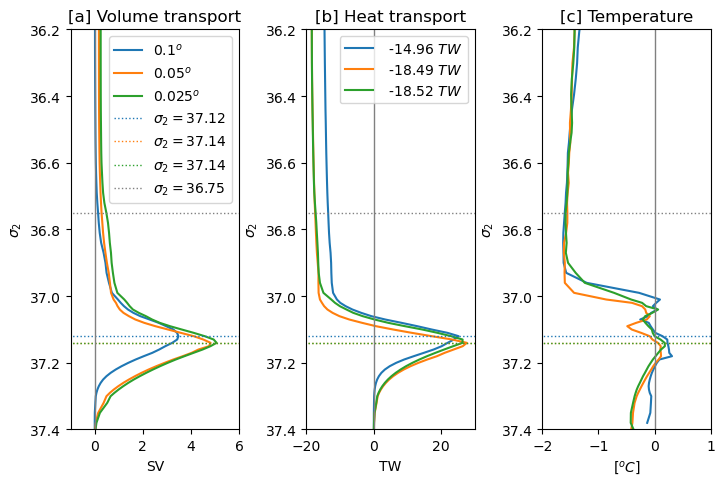

In [31]:
plt.figure(figsize=(8, 5))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(1,3,1)
plt.plot(MT01.where(MT01.lon>-200).where(MT01.lon<-150).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.where(MT01.lon>-200).where(MT01.lon>-150).rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.where(MT005.lon>-200).where(MT005.lon<-150).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.where(MT005.lon>-200).where(MT005.lon<-150).rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot(MT0025.where(MT0025.lon>-200).where(MT0025.lon<-150).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT0025.where(MT0025.lon>-200).where(MT0025.lon<-150).rho2_l[::-1]-1000,color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.12,37.12],':',color='tab:blue',lw=1,label=r"$\sigma_2=37.12$")
plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1,label=r"$\sigma_2=37.14$")
plt.plot([-5,15],[37.14,37.14],':',color='tab:green',lw=1,label=r"$\sigma_2=37.14$")
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1,label=r"$\sigma_2=36.75$")

plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('SV'),plt.ylabel(r"$\sigma_2$");plt.title('[a] Volume transport')
plt.ylim(37.4,36.2); plt.xlim(-1,6)
plt.legend()

RStotal01= np.round(RSpρ01_HT_totalmeanGW_nocumsum.sum(),2)
RStotal005= np.round(RSpρ005_HT_totalmeanGW_nocumsum.sum(),2)
RStotal0025= np.round(RSpρ0025_HT_totalmeanGW_nocumsum.sum(),2)

plt.subplot(1,3,2)
plt.plot(RSpρ01_HT_totalmeanGW,\
         RSpρ01_HT_totalmeanGW.rho2_l-1000, color='tab:blue', label=r" " + str(RStotal01.values) + " $TW$")
plt.plot(RSpρ005_HT_totalmeanGW,\
         RSpρ005_HT_totalmeanGW.rho2_l-1000, color='tab:orange', label=r" " + str(RStotal005.values) + " $TW$")
plt.plot(RSpρ0025_HT_totalmeanGW,\
         RSpρ0025_HT_totalmeanGW.rho2_l-1000, color='tab:green', label=r" " + str(RStotal0025.values) + " $TW$")
plt.plot([-50,50],[37.12,37.12],':',color='tab:blue',lw=1)
plt.plot([-50,50],[37.14,37.14],':',color='tab:orange',lw=1)
plt.plot([-50,50],[37.14,37.14],':',color='tab:green',lw=1)
plt.plot([-50,50],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('TW'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.4,36.2);plt.xlim(-20,30); plt.legend()

plt.subplot(1,3,3)
plt.plot(RST01ρmean_contour[::-1],\
         RST01ρmean_contour.rho2_l[::-1]-1000, color='tab:blue', label=r"$0.1^o$")
plt.plot(RST005ρmean_contour[::-1],\
         RST005ρmean_contour.rho2_l[::-1]-1000, color='tab:orange', label=r"$0.05^o$")
plt.plot(RST0025ρmean_contour[::-1],\
         RST0025ρmean_contour.rho2_l[::-1]-1000, color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.12,37.12],':',color='tab:blue',lw=1)
plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1)
plt.plot([-5,15],[37.14,37.14],':',color='tab:green',lw=1)
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
plt.ylim(37.4,36.2);plt.xlim(-2,1)

here what is interesting to analyze is what happens between panan01 and panan005, and once again, CSHT changes seem to be dictated by the DSW otflow

### **B&A** Bellingshausen and Amundsen seas  $[150^oW$ $57^oW]$

In [32]:
BApρ01_HT_totalmeanGW = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-57)\
    .where(pρ01_HT_contour.lon_bin_midpoints>-150)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
BApρ01_HT_totalmeanGW_nocumsum = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-57)\
    .where(pρ01_HT_contour.lon_bin_midpoints>-150)[::-1].sum('lon_bin_midpoints')/1e12)

BApρ005_HT_totalmeanGW = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-57)\
    .where(pρ005_HT_contour.lon_bin_midpoints>-150)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
BApρ005_HT_totalmeanGW_nocumsum = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-57)\
    .where(pρ005_HT_contour.lon_bin_midpoints>-150)[::-1].sum('lon_bin_midpoints')/1e12)

BApρ0025_HT_totalmeanGW = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-57)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>-150)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
BApρ0025_HT_totalmeanGW_nocumsum = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-57)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>-150)[::-1].sum('lon_bin_midpoints')/1e12)

In [33]:
BAT01ρmean_contour =T01ρmean_contour.where(pρ01_HT.lon_along_contour.isel(time=0)<-57)\
    .where(pρ01_HT.lon_along_contour.isel(time=0)>-150).weighted(Vol01ρmean_contour.fillna(0)).mean('contour_index').load()

BAT005ρmean_contour =T005ρmean_contour.where(pρ005_HT.lon_along_contour.isel(time=0)<-57)\
    .where(pρ005_HT.lon_along_contour.isel(time=0)>-150).weighted(Vol005ρmean_contour.fillna(0)).mean('contour_index').load()


BAT0025ρmean_contour =T0025ρmean_contour.where(pρ0025_HT.lon_along_contour.isel(time=0)<-57)\
    .where(pρ0025_HT.lon_along_contour.isel(time=0)>-150).weighted(Vol0025ρmean_contour.fillna(0)).mean('contour_index').load()

(-2.0, 1.5)

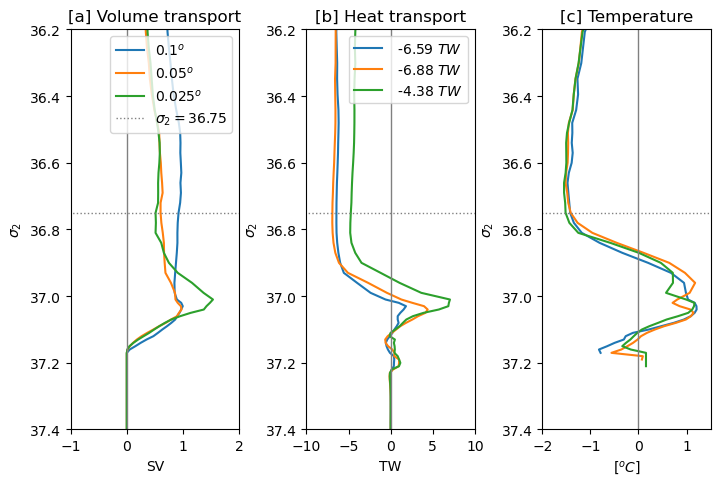

In [34]:
plt.figure(figsize=(8, 5))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(1,3,1)
plt.plot(MT01.where(MT01.lon>-150).where(MT01.lon<-57).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.where(MT01.lon>-150).where(MT01.lon>-57).rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.where(MT005.lon>-150).where(MT005.lon<-57).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.where(MT005.lon>-150).where(MT005.lon<-57).rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot(MT0025.where(MT0025.lon>-150).where(MT0025.lon<-57).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT0025.where(MT0025.lon>-150).where(MT0025.lon<-57).rho2_l[::-1]-1000,color='tab:green', label=r"$0.025^o$")
# plt.plot([-5,15],[37.12,37.12],':',color='tab:blue',lw=1,label=r"$\sigma_2=37.12$")
# plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1,label=r"$\sigma_2=37.14$")
# plt.plot([-5,15],[37.14,37.14],':',color='tab:green',lw=1,label=r"$\sigma_2=37.14$")
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1,label=r"$\sigma_2=36.75$")

plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('SV'),plt.ylabel(r"$\sigma_2$");plt.title('[a] Volume transport')
plt.ylim(37.4,36.2); plt.xlim(-1,2)
plt.legend()

BAtotal01= np.round(BApρ01_HT_totalmeanGW_nocumsum.sum(),2)
BAtotal005= np.round(BApρ005_HT_totalmeanGW_nocumsum.sum(),2)
BAtotal0025= np.round(BApρ0025_HT_totalmeanGW_nocumsum.sum(),2)

plt.subplot(1,3,2)
plt.plot(BApρ01_HT_totalmeanGW,\
         BApρ01_HT_totalmeanGW.rho2_l-1000, color='tab:blue', label=r" " + str(BAtotal01.values) + " $TW$")
plt.plot(BApρ005_HT_totalmeanGW,\
         BApρ005_HT_totalmeanGW.rho2_l-1000, color='tab:orange', label=r" " + str(BAtotal005.values) + " $TW$")
plt.plot(BApρ0025_HT_totalmeanGW,\
         BApρ0025_HT_totalmeanGW.rho2_l-1000, color='tab:green', label=r" " + str(BAtotal0025.values) + " $TW$")
# plt.plot([-50,50],[37.12,37.12],':',color='tab:blue',lw=1)
# plt.plot([-50,50],[37.14,37.14],':',color='tab:orange',lw=1)
# plt.plot([-50,50],[37.14,37.14],':',color='tab:green',lw=1)
plt.plot([-50,50],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('TW'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.4,36.2);plt.xlim(-10,10); plt.legend()

plt.subplot(1,3,3)
plt.plot(BAT01ρmean_contour[::-1],\
         BAT01ρmean_contour.rho2_l[::-1]-1000, color='tab:blue', label=r"$0.1^o$")
plt.plot(BAT005ρmean_contour[::-1],\
         BAT005ρmean_contour.rho2_l[::-1]-1000, color='tab:orange', label=r"$0.05^o$")
plt.plot(BAT0025ρmean_contour[::-1],\
         BAT0025ρmean_contour.rho2_l[::-1]-1000, color='tab:green', label=r"$0.025^o$")
# plt.plot([-5,15],[37.12,37.12],':',color='tab:blue',lw=1)
# plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1)
# plt.plot([-5,15],[37.14,37.14],':',color='tab:green',lw=1)
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
plt.ylim(37.4,36.2);plt.xlim(-2,1.5)

Temperatures dont change much in here, only in the densest layes. in turn, we shouldnt have DSW formation here either. So Im not sure on why we have the positive values in here.

### Weddell Sea  $[57^oW$ $30^oW]$

In [35]:
WSpρ01_HT_totalmeanGW = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-30)\
    .where(pρ01_HT_contour.lon_bin_midpoints>-57)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
WSpρ01_HT_totalmeanGW_nocumsum = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<-30)\
    .where(pρ01_HT_contour.lon_bin_midpoints>-57)[::-1].sum('lon_bin_midpoints')/1e12)

WSpρ005_HT_totalmeanGW = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-30)\
    .where(pρ005_HT_contour.lon_bin_midpoints>-57)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
WSpρ005_HT_totalmeanGW_nocumsum = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<-30)\
    .where(pρ005_HT_contour.lon_bin_midpoints>-57)[::-1].sum('lon_bin_midpoints')/1e12)

WSpρ0025_HT_totalmeanGW = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-30)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>-57)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
WSpρ0025_HT_totalmeanGW_nocumsum = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<-30)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>-57)[::-1].sum('lon_bin_midpoints')/1e12)

In [36]:
WST01ρmean_contour =T01ρmean_contour.where(pρ01_HT.lon_along_contour.isel(time=0)<-30)\
    .where(pρ01_HT.lon_along_contour.isel(time=0)>-57).weighted(Vol01ρmean_contour.fillna(0)).mean('contour_index').load()

WST005ρmean_contour =T005ρmean_contour.where(pρ005_HT.lon_along_contour.isel(time=0)<-30)\
    .where(pρ005_HT.lon_along_contour.isel(time=0)>-57).weighted(Vol005ρmean_contour.fillna(0)).mean('contour_index').load()


WST0025ρmean_contour =T0025ρmean_contour.where(pρ0025_HT.lon_along_contour.isel(time=0)<-30)\
    .where(pρ0025_HT.lon_along_contour.isel(time=0)>-57).weighted(Vol0025ρmean_contour.fillna(0)).mean('contour_index').load()

(-2.0, 1.0)

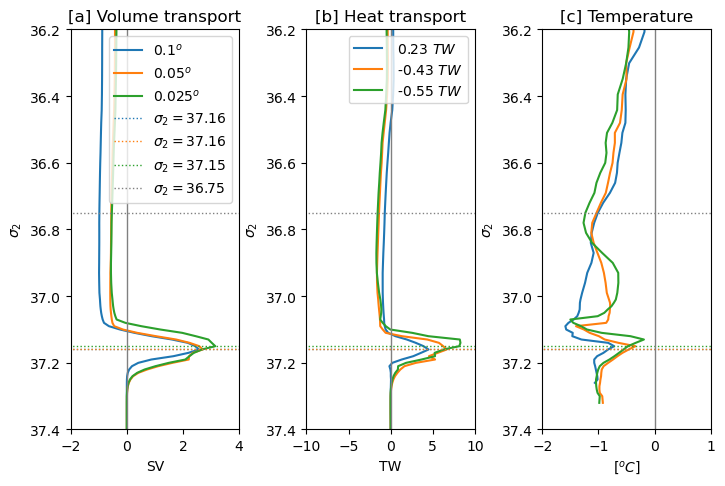

In [37]:
plt.figure(figsize=(8, 5))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(1,3,1)
plt.plot(MT01.where(MT01.lon>-57).where(MT01.lon<-30).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.where(MT01.lon>-57).where(MT01.lon>-30).rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.where(MT005.lon>-57).where(MT005.lon<-30).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.where(MT005.lon>-57).where(MT005.lon<-30).rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot(MT0025.where(MT0025.lon>-57).where(MT0025.lon<-30).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT0025.where(MT0025.lon>-57).where(MT0025.lon<-30).rho2_l[::-1]-1000,color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.16,37.16],':',color='tab:blue',lw=1,label=r"$\sigma_2=37.16$")
plt.plot([-5,15],[37.16,37.16],':',color='tab:orange',lw=1,label=r"$\sigma_2=37.16$")
plt.plot([-5,15],[37.15,37.15],':',color='tab:green',lw=1,label=r"$\sigma_2=37.15$")
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1,label=r"$\sigma_2=36.75$")

plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('SV'),plt.ylabel(r"$\sigma_2$");plt.title('[a] Volume transport')
plt.ylim(37.4,36.2); plt.xlim(-2,4)
plt.legend()

WStotal01= np.round(WSpρ01_HT_totalmeanGW_nocumsum.sum(),2)
WStotal005= np.round(WSpρ005_HT_totalmeanGW_nocumsum.sum(),2)
WStotal0025= np.round(WSpρ0025_HT_totalmeanGW_nocumsum.sum(),2)

plt.subplot(1,3,2)
plt.plot(WSpρ01_HT_totalmeanGW,\
         WSpρ01_HT_totalmeanGW.rho2_l-1000, color='tab:blue', label=r" " + str(WStotal01.values) + " $TW$")
plt.plot(WSpρ005_HT_totalmeanGW,\
         WSpρ005_HT_totalmeanGW.rho2_l-1000, color='tab:orange', label=r" " + str(WStotal005.values) + " $TW$")
plt.plot(WSpρ0025_HT_totalmeanGW,\
         WSpρ0025_HT_totalmeanGW.rho2_l-1000, color='tab:green', label=r" " + str(WStotal0025.values) + " $TW$")
plt.plot([-50,15],[37.16,37.16],':',color='tab:blue',lw=1)
plt.plot([-50,15],[37.16,37.16],':',color='tab:orange',lw=1)
plt.plot([-50,15],[37.15,37.15],':',color='tab:green',lw=1)
plt.plot([-50,15],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('TW'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.4,36.2);plt.xlim(-10,10); plt.legend()

plt.subplot(1,3,3)
plt.plot(WST01ρmean_contour[::-1],\
         WST01ρmean_contour.rho2_l[::-1]-1000, color='tab:blue', label=r"$0.1^o$")
plt.plot(WST005ρmean_contour[::-1],\
         WST005ρmean_contour.rho2_l[::-1]-1000, color='tab:orange', label=r"$0.05^o$")
plt.plot(WST0025ρmean_contour[::-1],\
         WST0025ρmean_contour.rho2_l[::-1]-1000, color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.16,37.16],':',color='tab:blue',lw=1)
plt.plot([-5,15],[37.16,37.16],':',color='tab:orange',lw=1)
plt.plot([-5,15],[37.15,37.15],':',color='tab:green',lw=1)
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
plt.ylim(37.4,36.2);plt.xlim(-2,1)

### Regional analysis

##### Shackelton ice shelf

This is a small reagion in East Antarctic Shelf, where warming has been observed, but the model has no DSW formantion (I think)

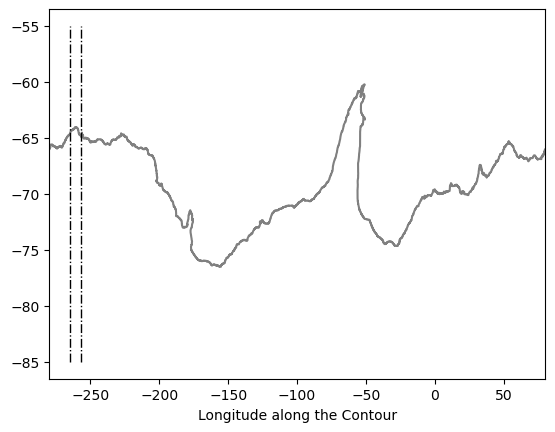

In [38]:
plt.plot(p005_ST.isel(time=0).lon_along_contour.drop('time'),
         p005_ST.isel(time=0).lat_along_contour.drop('time'), color='grey')
plt.xlabel('Longitude along the Contour'); plt.xlim(-280,80)
plt.plot([103-360,103-360],[-85,-55],lw=1,color='k',linestyle='-.')
plt.plot([95-360,95-360],[-85,-55],lw=1,color='k',linestyle='-.')

In [39]:
#limits
SELIM = 103-360
SWLIM = 95-360

In [40]:
SHpρ01_HT_totalmeanGW = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<SELIM)\
    .where(pρ01_HT_contour.lon_bin_midpoints>SWLIM)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
SHpρ01_HT_totalmeanGW_nocumsum = (pρ01_HT_contour.where(pρ01_HT_contour.lon_bin_midpoints<SELIM)\
    .where(pρ01_HT_contour.lon_bin_midpoints>SWLIM)[::-1].sum('lon_bin_midpoints')/1e12)

SHpρ005_HT_totalmeanGW = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<SELIM)\
    .where(pρ005_HT_contour.lon_bin_midpoints>SWLIM)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
SHpρ005_HT_totalmeanGW_nocumsum = (pρ005_HT_contour.where(pρ005_HT_contour.lon_bin_midpoints<SELIM)\
    .where(pρ005_HT_contour.lon_bin_midpoints>SWLIM)[::-1].sum('lon_bin_midpoints')/1e12)

SHpρ0025_HT_totalmeanGW = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<SELIM)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>SWLIM)[::-1].sum('lon_bin_midpoints').cumsum('rho2_l')/1e12)
SHpρ0025_HT_totalmeanGW_nocumsum = (pρ0025_HT_contour.where(pρ0025_HT_contour.lon_bin_midpoints<SELIM)\
    .where(pρ0025_HT_contour.lon_bin_midpoints>SWLIM)[::-1].sum('lon_bin_midpoints')/1e12)

In [41]:
SHT01ρmean_contour =T01ρmean_contour.where(pρ01_HT.lon_along_contour.isel(time=0)<SELIM)\
    .where(pρ01_HT.lon_along_contour.isel(time=0)>SWLIM).weighted(Vol01ρmean_contour.fillna(0)).mean('contour_index').load()

SHT005ρmean_contour =T005ρmean_contour.where(pρ005_HT.lon_along_contour.isel(time=0)<SELIM)\
    .where(pρ005_HT.lon_along_contour.isel(time=0)>SWLIM).weighted(Vol005ρmean_contour.fillna(0)).mean('contour_index').load()

SHT0025ρmean_contour =T0025ρmean_contour.where(pρ0025_HT.lon_along_contour.isel(time=0)<SELIM)\
    .where(pρ0025_HT.lon_along_contour.isel(time=0)>SWLIM).weighted(Vol0025ρmean_contour.fillna(0)).mean('contour_index').load()

(-2.0, 1.0)

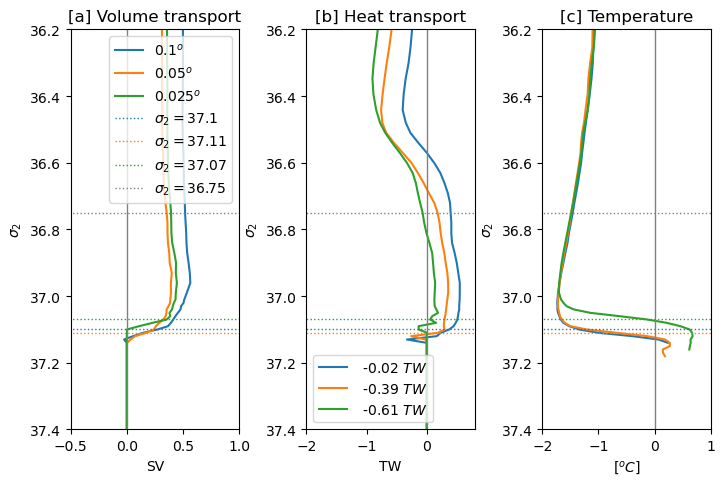

In [42]:
plt.figure(figsize=(8, 5))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(1,3,1)
plt.plot(MT01.where(MT01.lon>SWLIM).where(MT01.lon<SELIM).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.where(MT01.lon>SWLIM).where(MT01.lon>SELIM).rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.where(MT005.lon>SWLIM).where(MT005.lon<SELIM).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.where(MT005.lon>SWLIM).where(MT005.lon<SELIM).rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot(MT0025.where(MT0025.lon>SWLIM).where(MT0025.lon<SELIM).mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT0025.where(MT0025.lon>SWLIM).where(MT0025.lon<SELIM).rho2_l[::-1]-1000,color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.1,37.1],':',color='tab:blue',lw=1,label=r"$\sigma_2=37.1$")
plt.plot([-5,15],[37.11,37.11],':',color='tab:orange',lw=1,label=r"$\sigma_2=37.11$")
plt.plot([-5,15],[37.07,37.07],':',color='tab:green',lw=1,label=r"$\sigma_2=37.07$")
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1,label=r"$\sigma_2=36.75$")

plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('SV'),plt.ylabel(r"$\sigma_2$");plt.title('[a] Volume transport')
plt.ylim(37.4,36.2); plt.xlim(-0.5,1)
plt.legend()

SHtotal01= np.round(SHpρ01_HT_totalmeanGW_nocumsum.sum(),2)
SHtotal005= np.round(SHpρ005_HT_totalmeanGW_nocumsum.sum(),2)
SHtotal0025= np.round(SHpρ0025_HT_totalmeanGW_nocumsum.sum(),2)

plt.subplot(1,3,2)
plt.plot(SHpρ01_HT_totalmeanGW,\
         SHpρ01_HT_totalmeanGW.rho2_l-1000, color='tab:blue', label=r" " + str(SHtotal01.values) + " $TW$")
plt.plot(SHpρ005_HT_totalmeanGW,\
         SHpρ005_HT_totalmeanGW.rho2_l-1000, color='tab:orange', label=r" " + str(SHtotal005.values) + " $TW$")
plt.plot(SHpρ0025_HT_totalmeanGW,\
         SHpρ0025_HT_totalmeanGW.rho2_l-1000, color='tab:green', label=r" " + str(SHtotal0025.values) + " $TW$")
plt.plot([-5,15],[37.1,37.1],':',color='tab:blue',lw=1)
plt.plot([-5,15],[37.11,37.11],':',color='tab:orange',lw=1)
plt.plot([-5,15],[37.07,37.07],':',color='tab:green',lw=1)
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('TW'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.4,36.2);plt.xlim(-2,.8); plt.legend(loc='lower left')

plt.subplot(1,3,3)
plt.plot(SHT01ρmean_contour[::-1],\
         SHT01ρmean_contour.rho2_l[::-1]-1000, color='tab:blue', label=r"$0.1^o$")
plt.plot(SHT005ρmean_contour[::-1],\
         SHT005ρmean_contour.rho2_l[::-1]-1000, color='tab:orange', label=r"$0.05^o$")
plt.plot(SHT0025ρmean_contour[::-1],\
         SHT0025ρmean_contour.rho2_l[::-1]-1000, color='tab:green', label=r"$0.025^o$")
plt.plot([-5,15],[37.1,37.1],':',color='tab:blue',lw=1)
plt.plot([-5,15],[37.11,37.11],':',color='tab:orange',lw=1)
plt.plot([-5,15],[37.07,37.07],':',color='tab:green',lw=1)
plt.plot([-5,15],[36.75,36.75],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
plt.ylim(37.4,36.2);plt.xlim(-2,1)

In [43]:
SH_CDW01 = SHpρ01_HT_totalmeanGW_nocumsum.sel(rho2_l=slice(1037.1,1036.75)).sum()
SH_CDW005 = SHpρ005_HT_totalmeanGW_nocumsum.sel(rho2_l=slice(1037.11,1036.75)).sum()
SH_CDW0025 = SHpρ0025_HT_totalmeanGW_nocumsum.sel(rho2_l=slice(1037.07,1036.75)).sum()

In [44]:
SH_CDW01.values,SH_CDW005.values,SH_CDW0025.values

(array(0.02520068), array(-0.00251837), array(-0.12701113))

**IDEA FOR NEXT EVALUATION** Separate these results by shelf regimes. This way we can separate patterns of resolution changes that are rules by DSW and the ones that are not ruled by DSW

#### Shelf Regions Classification